In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import config

# 01 - EDA va phan tich 3B

Notebook này trả lời checklist EDA của giảng viên (quan sát đại diện cho gì, target, phân bố lớp, missing, trùng lặp, biến ít thông tin, ngữ cảnh vận hành) và kết luận 3B (**Broken, Bad Quality, Background**), gắn với 6 câu hỏi của bài giảng: Structure, Distribution, Quality, Relationships, Time, Context.

**Quy ước dùng dữ liệu:** EDA được nhìn toàn bộ dữ liệu để *hiểu*, nhưng mọi con số dùng để *quyết định* xử lý (ngưỡng thiếu, cột bị bỏ) phải tính trên **train**. Ô nào dùng toàn bộ dữ liệu, ô nào dùng train đều được ghi rõ (`[TOÀN BỘ]` hoặc `[TRAIN]`). Notebook không điền missing, không scale, không thử mô hình: đó là việc của `src/preprocess.py`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_data
from src.split import time_split, describe_split

config.FIGURES_DIR.mkdir(exist_ok=True)   # tạo thư mục figures nếu chưa có
COLOR_PASS = "#4C78A8"                    # xanh: Pass (dùng xuyên suốt notebook)
COLOR_FAIL = "#E45756"                    # đỏ cam: Fail (dùng xuyên suốt notebook)

## 1. Cấu trúc dữ liệu (Structure)

**Câu hỏi:** một quan sát đại diện cho cái gì, dữ liệu có hình dạng ra sao?
**Cách làm:** nạp dữ liệu, chia train/test (80/20 theo thời gian), in kích thước, kiểu dữ liệu và khoảng thời gian.

Mỗi quan sát (một dòng) là **một lần đo của một lô sản xuất tại một thời điểm**, gồm 590 số đo cảm biến/quy trình đã ẩn danh và một nhãn Pass/Fail.

In [3]:
# [TOÀN BỘ] nạp dữ liệu, rồi chia theo thời gian (train = 80% dòng đầu, test = 20% dòng cuối)
X, y, timestamps = load_data()
X_train, X_test, y_train, y_test = time_split(X, y, timestamps)

print("X toàn bộ :", X.shape)
print("X_train   :", X_train.shape)
print("X_test    :", X_test.shape)
print("Số cột    :", X.shape[1])
print("Kiểu dữ liệu của các cột:", list(X.dtypes.unique()))
print("Thời gian :", timestamps.min(), "->", timestamps.max())
test_start = timestamps.loc[X_test.index[0]]     # index gốc được giữ nguyên sau khi chia
print("Test bắt đầu lúc:", test_start)

X toàn bộ : (1567, 590)
X_train   : (1253, 590)
X_test    : (314, 590)
Số cột    : 590
Kiểu dữ liệu của các cột: [dtype('float64')]
Thời gian : 2008-07-19 11:55:00 -> 2008-10-17 06:07:00
Test bắt đầu lúc: 2008-10-02 20:54:00


**Nhận xét.** Dữ liệu có 1567 lô x 590 cột, tất cả là `float64`. Train có 1253 lô, test có 314 lô. Dữ liệu trải từ 19/07/2008 11:55 đến 17/10/2008 06:07 (khoảng 3 tháng). Test bắt đầu từ 02/10/2008 20:54, tức là chỉ gồm các lô mới nhất. Không có cột nào là tên cảm biến hay mã sản phẩm: 590 cột chỉ được đánh số 0..589.

## 2. Target và phân bố lớp (Distribution)

**Câu hỏi:** nhãn là gì, hai lớp có cân bằng không? **Cách làm:** đếm Pass/Fail trên toàn bộ dữ liệu và vẽ biểu đồ cột.

Pass: 1463 | Fail: 104 | Tỉ lệ Fail: 0.0664
Nếu đoán toàn bộ là Pass thì đúng: 0.9336


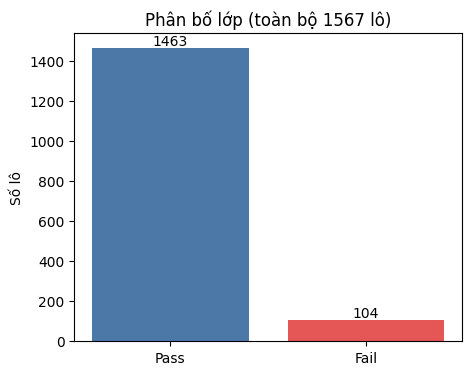

In [4]:
# [TOÀN BỘ] đếm số lô mỗi lớp (config.PASS = 0, config.FAIL = 1)
n_pass = int((y == config.PASS).sum())
n_fail = int((y == config.FAIL).sum())
fail_rate = n_fail / len(y)
print("Pass:", n_pass, "| Fail:", n_fail, "| Tỉ lệ Fail:", round(fail_rate, 4))
print("Nếu đoán toàn bộ là Pass thì đúng:", round(n_pass / len(y), 4))

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Pass", "Fail"], [n_pass, n_fail], color=[COLOR_PASS, COLOR_FAIL])
ax.bar_label(bars)                       # ghi số lượng trên đầu cột
ax.set_title("Phân bố lớp (toàn bộ 1567 lô)")
ax.set_ylabel("Số lô")
plt.savefig(config.FIGURES_DIR / "eda_label_dist.png", dpi=150, bbox_inches="tight")
plt.show()

**Nhận xét.** Có 1463 lô Pass và 104 lô Fail, tỉ lệ Fail là 6,64%: dữ liệu **mất cân bằng mạnh**. Một mô hình đoán toàn bộ là Pass vẫn đúng 93,36% mà không phát hiện được lô lỗi nào, nên **không dùng accuracy** để đánh giá. Cần các chỉ số nhìn vào lớp Fail như recall, precision, F1 hoặc PR-AUC.

## 3. Thời gian (Time)

**Câu hỏi:** tỉ lệ lỗi có đều theo thời gian không? **Cách làm:** nhóm các lô theo tuần, tính số lô và tỉ lệ Fail từng tuần ([TOÀN BỘ] dữ liệu để hiểu), rồi so sánh train với test.

In [5]:
# [TOÀN BỘ] nhóm theo tuần: mỗi lô thuộc về tuần (thứ Hai đến Chủ nhật) chứa timestamp của nó
week = timestamps.dt.to_period("W")
weekly = pd.DataFrame({"week": week, "fail": y}).groupby("week")["fail"].agg(["size", "mean"])
weekly.columns = ["n_lo", "fail_rate"]
print(weekly.round(4))

                       n_lo  fail_rate
week                                  
2008-07-14/2008-07-20    13     0.2308
2008-07-21/2008-07-27    21     0.0952
2008-07-28/2008-08-03    48     0.2083
2008-08-04/2008-08-10   108     0.1296
2008-08-11/2008-08-17    51     0.1373
2008-08-18/2008-08-24   208     0.1058
2008-08-25/2008-08-31   169     0.0414
2008-09-01/2008-09-07   133     0.0150
2008-09-08/2008-09-14    95     0.0421
2008-09-15/2008-09-21   154     0.0325
2008-09-22/2008-09-28   166     0.0241
2008-09-29/2008-10-05   169     0.0888
2008-10-06/2008-10-12   138     0.0580
2008-10-13/2008-10-19    94     0.0106


In [6]:
# [TRAIN vs TEST] số mẫu, số Fail, tỉ lệ Fail của hai phần
split_table = describe_split(y_train, y_test)

       n_samples  n_fail  fail_rate
train       1253      87     0.0694
test         314      17     0.0541


In [7]:
# [TOÀN BỘ] biểu đồ tỉ lệ Fail theo tuần
week_labels = weekly.index.start_time.strftime("%d/%m")       # nhãn trục x = ngày đầu tuần
positions = np.arange(len(weekly))
test_week = test_start.to_period("W")
test_week_position = list(weekly.index).index(test_week)     # tuần chứa chỗ bắt đầu test
day_fraction = (test_start - test_week.start_time) / pd.Timedelta(days=7)

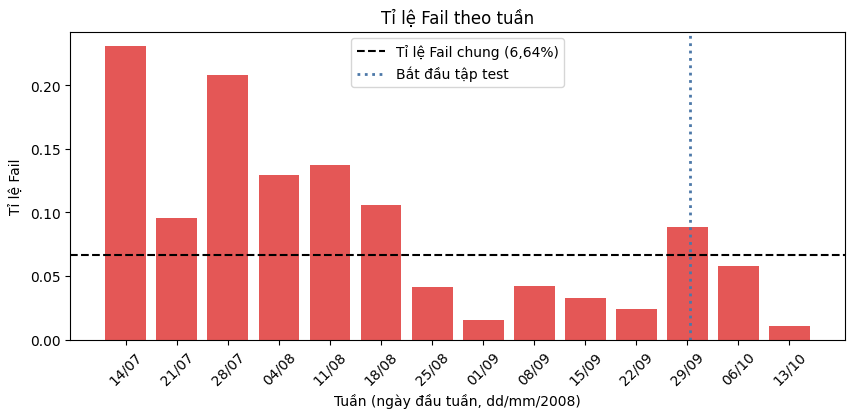

In [8]:
# [TOÀN BỘ] vẽ biểu đồ cột tỉ lệ Fail theo tuần
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(positions, weekly["fail_rate"], color=COLOR_FAIL)
ax.axhline(y.mean(), color="black", linestyle="--", label="Tỉ lệ Fail chung (6,64%)")
ax.axvline(test_week_position - 0.5 + day_fraction, color=COLOR_PASS, linestyle=":", linewidth=2, label="Bắt đầu tập test")
ax.set_xticks(positions)
ax.set_xticklabels(week_labels, rotation=45)
ax.set_title("Tỉ lệ Fail theo tuần")
ax.set_xlabel("Tuần (ngày đầu tuần, dd/mm/2008)")
ax.set_ylabel("Tỉ lệ Fail")
ax.legend()
plt.savefig(config.FIGURES_DIR / "eda_fail_by_week.png", dpi=150, bbox_inches="tight")
plt.show()

**Nhận xét.** Tỉ lệ Fail **không đều theo thời gian** (có drift). Các tuần đầu (14/07 đến 17/08) dao động khoảng 9,5% đến 23,1% (tuần đầu chỉ có 13 lô, 23,1% là 3 lô Fail). Sang tháng 9 tỉ lệ giảm còn khoảng 1,5% đến 4,2%, rồi tuần 29/09 đến 05/10 tăng lại lên 8,9%. Tỉ lệ Fail của train là 6,94% (87/1253) còn của test là 5,41% (17/314). Vì tỉ lệ lỗi và điều kiện sản xuất đổi theo thời gian, ta **chia theo thời gian** (học từ lô cũ, dự đoán lô mới) chứ không chia ngẫu nhiên.

## 4. BROKEN: dữ liệu thiếu (Quality)

**Câu hỏi:** thiếu nhiều không, thiếu ở đâu, có xóa dòng được không? **Cách làm:** (a) đếm ô thiếu [TOÀN BỘ]; (b) tỉ lệ thiếu từng cột [TRAIN]; (c) so sánh số cột thiếu >70% khi tính trên train, toàn bộ và test; (d) số ô thiếu theo dòng; (e) kiểm tra nhanh xem số ô thiếu có liên quan đến nhãn không.

Chỉ con số tính trên **train** mới dùng để quyết định cột nào bị bỏ. Hai cách tính còn lại ở (c) chỉ để so sánh.

In [9]:
# (a) [TOÀN BỘ] tổng số ô thiếu (NaN) và phần trăm trên tổng số ô
total_missing = int(X.isna().sum().sum())
print("Tổng số ô thiếu:", total_missing)
print("Phần trăm trên tổng số ô:", round(100 * total_missing / X.size, 2), "%")

Tổng số ô thiếu: 41951
Phần trăm trên tổng số ô: 4.54 %


In [10]:
# (b) [TRAIN] tỉ lệ thiếu của từng cột (trung bình của True/False theo cột)
missing_rate_train = X_train.isna().mean()
print("Số cột thiếu > 70%:", int((missing_rate_train > config.MISSING_THRESHOLD).sum()))
print("Số cột thiếu > 50%:", int((missing_rate_train > 0.5).sum()))
print("Số cột có thiếu (> 0%):", int((missing_rate_train > 0).sum()), "trên", X_train.shape[1])
print("10 cột thiếu nhiều nhất (index cột: tỉ lệ thiếu):")
print(missing_rate_train.sort_values(ascending=False).head(10).round(4))

Số cột thiếu > 70%: 20
Số cột thiếu > 50%: 24
Số cột có thiếu (> 0%): 442 trên 590
10 cột thiếu nhiều nhất (index cột: tỉ lệ thiếu):
157    0.9034
158    0.9034
292    0.9034
293    0.9034
492    0.8899
85     0.8899
358    0.8899
220    0.8899
517    0.7757
516    0.7757
dtype: float64


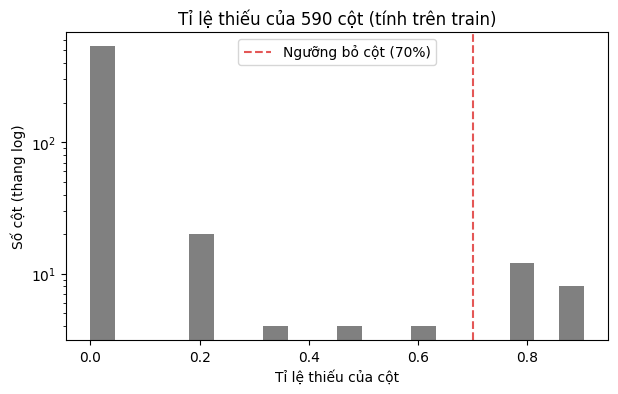

In [11]:
# (b) [TRAIN] histogram tỉ lệ thiếu của các cột
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(missing_rate_train, bins=20, color="gray")
ax.axvline(config.MISSING_THRESHOLD, color=COLOR_FAIL, linestyle="--", label="Ngưỡng bỏ cột (70%)")
ax.set_yscale("log")                     # thang log vì đa số cột gần như không thiếu
ax.set_title("Tỉ lệ thiếu của 590 cột (tính trên train)")
ax.set_xlabel("Tỉ lệ thiếu của cột")
ax.set_ylabel("Số cột (thang log)")
ax.legend()
plt.savefig(config.FIGURES_DIR / "eda_missing_hist.png", dpi=150, bbox_inches="tight")
plt.show()

**Nhận xét (a, b).** Có 41.951 ô thiếu, chiếm 4,54% toàn bộ dữ liệu. Trên train, 442 trong 590 cột có ít nhất một ô thiếu, 24 cột thiếu hơn 50% và **20 cột thiếu hơn 70%** (cao nhất 90,34%). Histogram (thang log) cho thấy đa số cột gần như không thiếu, có một nhóm nhỏ thiếu khoảng 20%, và nhóm 20 cột nằm bên phải ngưỡng 70% thiếu rất nhiều. Nhóm cột thiếu nhiều này là ứng viên bị bỏ ở bước tiền xử lý.

In [12]:
# (c) so sánh số cột thiếu > 70% khi tính trên 3 tập khác nhau (chỉ train được dùng để quyết định)
threshold = config.MISSING_THRESHOLD
missing_rate_all = X.isna().mean()
missing_rate_test = X_test.isna().mean()
print("Cột thiếu > 70% tính trên TRAIN   :", int((missing_rate_train > threshold).sum()))
print("Cột thiếu > 70% tính trên TOÀN BỘ :", int((missing_rate_all > threshold).sum()))
print("Cột thiếu > 70% tính trên TEST    :", int((missing_rate_test > threshold).sum()))
only_in_train = (missing_rate_train > threshold) & (missing_rate_test <= threshold)
print("Cột > 70% ở train nhưng <= 70% ở test:", int(only_in_train.sum()))

Cột thiếu > 70% tính trên TRAIN   : 20
Cột thiếu > 70% tính trên TOÀN BỘ : 8
Cột thiếu > 70% tính trên TEST    : 16
Cột > 70% ở train nhưng <= 70% ở test: 12


**Nhận xét (c).** Cùng một ngưỡng 70%, tính trên train được 20 cột, trên toàn bộ dữ liệu chỉ 8 cột, trên test 16 cột. Có 12 cột thiếu quá 70% ở train nhưng không quá 70% ở test. Vậy **thiếu dữ liệu tập trung theo thời gian** (nhiều cột bị thiếu gần hết trong một giai đoạn). Vì thế quyết định bỏ cột phải dựa trên train: tính trên toàn bộ dữ liệu sẽ cho kết quả khác và còn dùng cả thông tin của test.

In [13]:
# (d) số ô thiếu trên mỗi dòng
missing_per_row_all = X.isna().sum(axis=1)
missing_per_row_train = X_train.isna().sum(axis=1)
print("[TOÀN BỘ] median số ô thiếu mỗi dòng:", missing_per_row_all.median())
print("[TOÀN BỘ] ít nhất một dòng thiếu:", int(missing_per_row_all.min()), "ô")
print("[TOÀN BỘ] số dòng không thiếu ô nào:", int((missing_per_row_all == 0).sum()))
print("[TRAIN]   median số ô thiếu mỗi dòng:", missing_per_row_train.median())

[TOÀN BỘ] median số ô thiếu mỗi dòng: 24.0
[TOÀN BỘ] ít nhất một dòng thiếu: 4 ô
[TOÀN BỘ] số dòng không thiếu ô nào: 0
[TRAIN]   median số ô thiếu mỗi dòng: 28.0


**Nhận xét (d).** Trung vị là 24 ô thiếu mỗi dòng (toàn bộ), thậm chí dòng ít thiếu nhất vẫn thiếu 4 ô, và **không có dòng nào đầy đủ** (0/1567). Do đó không thể xóa dòng thiếu (sẽ mất hết dữ liệu): phải **điền giá trị thiếu** (median) và nên **giữ cột đánh dấu thiếu**.

In [14]:
# (e) [TRAIN] chia dòng thành 2 nhóm theo số ô thiếu so với median của train, so sánh tỉ lệ Fail
median_missing = missing_per_row_train.median()
many_missing = missing_per_row_train > median_missing
print("Median số ô thiếu (train):", median_missing)
print("Nhóm thiếu nhiều hơn median:", int(many_missing.sum()), "dòng, tỉ lệ Fail =", round(y_train[many_missing].mean(), 4))
print("Nhóm thiếu <= median       :", int((~many_missing).sum()), "dòng, tỉ lệ Fail =", round(y_train[~many_missing].mean(), 4))

Median số ô thiếu (train): 28.0
Nhóm thiếu nhiều hơn median: 430 dòng, tỉ lệ Fail = 0.0535
Nhóm thiếu <= median       : 823 dòng, tỉ lệ Fail = 0.0778


**Nhận xét (e).** Median của train là 28 ô. Nhóm thiếu nhiều hơn median (430 dòng) có tỉ lệ Fail 5,35%, nhóm còn lại (823 dòng) có 7,78%. Vậy ở mức tổng số ô thiếu mỗi dòng, **không thấy** dòng thiếu nhiều thì dễ Fail hơn (thậm chí hơi ngược lại). Kết quả này còn lẫn với yếu tố thời gian (số ô thiếu và tỉ lệ Fail đều thay đổi theo thời gian) và chưa xét từng cột riêng lẻ, nên chưa đủ để kết luận "thiếu dữ liệu là tín hiệu". Cột đánh dấu thiếu được giữ lại để mô hình tự quyết định, hiệu quả thật sẽ được đo ở thí nghiệm ablation.

## 5. BAD QUALITY: nhiễu và biến ít thông tin (Quality, Distribution)

**Câu hỏi:** có cột vô dụng, dòng trùng, giá trị cực đoan không? **Cách làm:** đếm cột hằng số [TRAIN] (có so với toàn bộ), dòng trùng lặp [TOÀN BỘ], và tỉ lệ giá trị có |z-score| > 3 [TRAIN]. Chỉ quan sát, không xóa hay sửa giá trị nào.

In [15]:
# (a) cột hằng số: chỉ có tối đa 1 giá trị khác nhau (nunique bỏ qua NaN)
constant_train = int((X_train.nunique() <= 1).sum())
constant_all = int((X.nunique() <= 1).sum())
duplicated_rows = int(X.duplicated().sum())
print("[TRAIN]   số cột hằng số:", constant_train)
print("[TOÀN BỘ] số cột hằng số:", constant_all)
print("[TOÀN BỘ] số dòng trùng lặp:", duplicated_rows)

[TRAIN]   số cột hằng số: 122
[TOÀN BỘ] số cột hằng số: 116
[TOÀN BỘ] số dòng trùng lặp: 0


In [16]:
# (b) [TRAIN] ngoại lệ: z-score = (giá trị - mean) / std của từng cột, bỏ cột hằng số (std = 0)
X_varying = X_train.loc[:, X_train.nunique() > 1]
z_scores = (X_varying - X_varying.mean()) / X_varying.std()
n_extreme = int((z_scores.abs() > 3).sum().sum())          # số giá trị có |z| > 3
n_not_missing = int(z_scores.notna().sum().sum())          # tổng số giá trị không thiếu
print("Số cột dùng để tính:", X_varying.shape[1])
print("Số giá trị |z| > 3:", n_extreme, "trên", n_not_missing)
print("Phần trăm:", round(100 * n_extreme / n_not_missing, 2), "%")

Số cột dùng để tính:

 468
Số giá trị |z| > 3: 5151 trên 552285
Phần trăm: 0.93 %


**Nhận xét.** Train có 122 cột hằng số (trên toàn bộ dữ liệu là 116; train ít dòng hơn nên có thêm cột không đổi). Các cột này không phân biệt được Pass/Fail và sẽ bị bỏ. **Không có dòng trùng lặp** (0). Về ngoại lệ, 0,93% giá trị không thiếu có |z| > 3; con số này cao hơn mức khoảng 0,27% của phân phối chuẩn, tức là có nhiều giá trị cực đoan. Tuy vậy ta **không loại bỏ** chúng: giá trị bất thường của cảm biến có thể chính là tín hiệu của lô lỗi (khớp với quyết định không có bước outlier trong pipeline), và các mô hình dựa trên cây ít nhạy với ngoại lệ.

## 6. Quan hệ với nhãn (Relationships)

**Câu hỏi:** cảm biến nào liên quan đến Pass/Fail, tín hiệu mạnh hay yếu? **Cách làm:** [TRAIN] tính tương quan từng cột với `y` (bỏ cột hằng số vì không tính được), lấy 10 cột mạnh nhất, vẽ biểu đồ và boxplot tách Pass/Fail cho 4 cột đầu. Tương quan chỉ mô tả mức độ đi cùng nhau, **không phải quan hệ nhân quả**.

Số cột tính được tương quan: 468
59     0.1715
85    -0.1439
431    0.1293
103    0.1282
158    0.1225
510    0.1217
358    0.1213
430    0.1208
293    0.1188
434    0.1187
dtype: float64


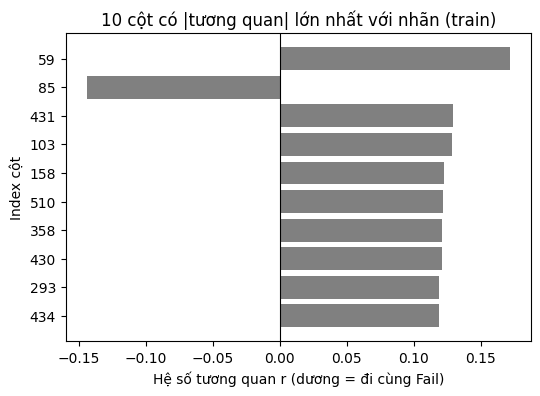

In [17]:
# [TRAIN] tương quan của từng cột với nhãn (y: 1 = Fail nên r > 0 nghĩa là giá trị cao đi cùng Fail)
X_varying = X_train.loc[:, X_train.nunique() > 1]
correlation = X_varying.corrwith(y_train).dropna()
top10_columns = correlation.abs().sort_values(ascending=False).head(10).index
top10_corr = correlation[top10_columns]
print("Số cột tính được tương quan:", len(correlation))
print(top10_corr.round(4))

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(top10_corr.index.astype(str)[::-1], top10_corr.values[::-1], color="gray")   # đảo để cột mạnh nhất ở trên
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("10 cột có |tương quan| lớn nhất với nhãn (train)")
ax.set_xlabel("Hệ số tương quan r (dương = đi cùng Fail)")
ax.set_ylabel("Index cột")
plt.savefig(config.FIGURES_DIR / "eda_top_corr.png", dpi=150, bbox_inches="tight")
plt.show()

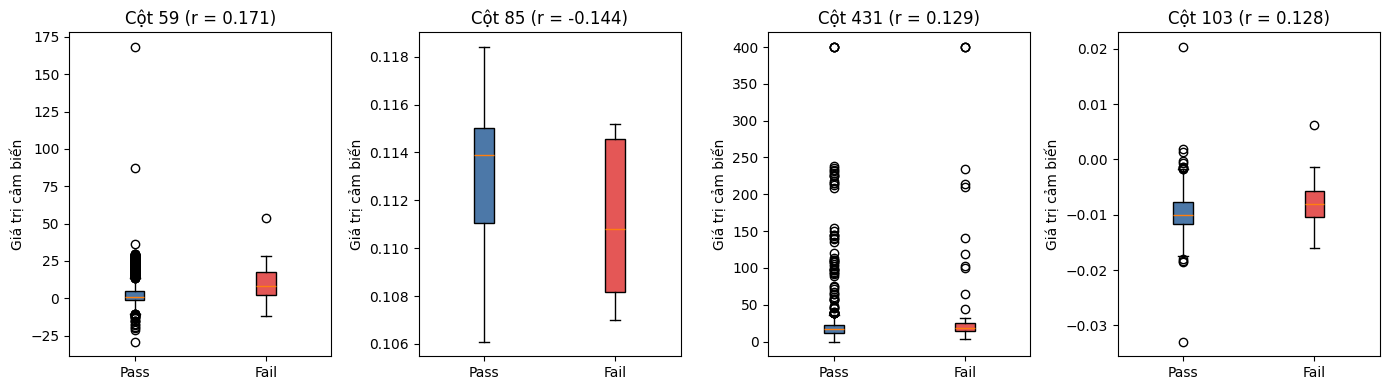

In [18]:
# [TRAIN] boxplot Pass vs Fail cho 4 cột có |tương quan| lớn nhất
top4_columns = list(top10_columns[:4])
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, column in zip(axes, top4_columns):
    pass_values = X_train[column][y_train == config.PASS].dropna()
    fail_values = X_train[column][y_train == config.FAIL].dropna()
    box = ax.boxplot([pass_values, fail_values], patch_artist=True)
    box["boxes"][0].set_facecolor(COLOR_PASS)
    box["boxes"][1].set_facecolor(COLOR_FAIL)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Pass", "Fail"])
    ax.set_title("Cột " + str(column) + " (r = " + str(round(correlation[column], 3)) + ")")
    ax.set_ylabel("Giá trị cảm biến")
fig.tight_layout()                       # tránh nhãn trục của các ô con đè lên nhau
plt.savefig(config.FIGURES_DIR / "eda_top_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

**Nhận xét.** Tín hiệu của từng cảm biến **rất yếu**: |r| lớn nhất chỉ 0,1715 (cột 59), 10 cột đứng đầu có |r| từ 0,1187 đến 0,1715. Với r = 0,17 thì chỉ giải thích được khoảng 3% phương sai của nhãn. Trên boxplot, hộp Pass và Fail của cùng một cột **chồng lấn**: trung vị Fail có lệch so với Pass (rõ nhất ở cột 59 và 85) nhưng vùng giá trị của hai lớp vẫn đè lên nhau, và còn nhiều điểm ngoại lệ ở cả hai lớp, nên không cột nào tách được hai lớp bằng một ngưỡng đơn giản. Vì vậy cần mô hình **kết hợp nhiều cảm biến** và có bước chọn đặc trưng. Lưu ý thêm: có 468 cột được xét, nên một vài cột đứng đầu có thể chỉ do ngẫu nhiên; đó cũng là lý do không nên kết luận nhân quả từ bảng này.

## 7. BACKGROUND: ngữ cảnh vận hành (Context)

*(Chỉ markdown, không có code.)* Câu hỏi: dữ liệu cho ta biết gì và **không** cho ta biết gì về nhà máy?

**Dữ liệu CÓ:**
- Timestamp của từng lô (từ 19/07/2008 đến 17/10/2008).
- Nhãn Pass/Fail cho từng lô (1463 Pass, 104 Fail).
- 590 số đo cảm biến/quy trình, đã ẩn danh, đánh số 0..589.

**Dữ liệu KHÔNG CÓ:**
- Tên và ý nghĩa của cảm biến, đơn vị đo.
- Mã máy, dây chuyền, công đoạn.
- Loại sản phẩm hay công thức (recipe).
- Điều kiện môi trường (nhiệt độ, độ ẩm, ca làm việc, người vận hành).
- Nguyên nhân gây lỗi, loại lỗi (nhãn chỉ có Pass/Fail).
- Thời điểm gắn nhãn so với thời điểm đo (không biết kết quả kiểm tra được ghi sau bao lâu).

**Hệ quả:**
- Không giải thích được một cảm biến cụ thể là gì hay hành động nào cần thực hiện trên máy.
- Không phân biệt được lỗi do máy, do công thức hay do nguyên liệu.
- Giải thích mô hình (explain) chỉ ở mức **"cột số nào đóng góp nhiều vào dự đoán"**, không phải nguyên nhân.
- Không biết các giai đoạn thiếu dữ liệu hay tỉ lệ lỗi cao (mục 3, mục 4) là do thay đổi quy trình, hỏng cảm biến hay lý do khác.

## 8. Kết luận 3B

| 3B | Bằng chứng (số thật từ notebook) | Hệ quả | Cách xử lý ở bước tiền xử lý |
|---|---|---|---|
| **Broken** (thiếu dữ liệu) | 41.951 ô thiếu (4,54%); 0/1567 dòng đầy đủ, median 24 ô thiếu mỗi dòng; 20 cột thiếu >70% trên train (8 trên toàn bộ, 16 trên test, 12 cột lệch giữa train và test) | Không thể xóa dòng; số cột bị bỏ phụ thuộc vào cách tính nên phải tính trên train; thiếu dữ liệu thay đổi theo thời gian | Bỏ cột thiếu >70% theo train (`MissingRateSelector`), điền median, thêm cột đánh dấu thiếu (EDA chưa chứng minh nó là tín hiệu; ablation sẽ đo) |
| **Bad Quality** (nhiễu, ít thông tin) | 122 cột hằng số trên train; 0 dòng trùng; 0,93% giá trị có \|z\| > 3; tín hiệu từng cột yếu (\|r\| lớn nhất 0,1715) | Nhiều cột vô dụng; có giá trị cực đoan nhưng chưa biết là nhiễu hay tín hiệu lỗi | Bỏ cột hằng số (`VarianceThreshold`), `StandardScaler`, chọn K đặc trưng (`SelectKBest`); **không** loại ngoại lệ |
| **Background** (ngữ cảnh) | Chỉ có timestamp, nhãn, 590 cột ẩn danh; không có tên cảm biến, mã máy, sản phẩm, nguyên nhân lỗi; tỉ lệ Fail đổi theo thời gian (train 6,94% so với test 5,41%) | Không giải thích được nguyên nhân; kết quả test (17 lô Fail) dao động mạnh; mô hình có thể lỗi thời khi quy trình đổi | Chia theo thời gian; ghi vào phần hạn chế của báo cáo; chỉ giải thích ở mức "cột nào đóng góp" |

**Cần thông tin gì thêm trước khi triển khai ở nhà máy thật?** Cần tên và đơn vị của cảm biến, mã máy/công đoạn/loại sản phẩm để biết cột nào ứng với bộ phận nào; loại lỗi và nguyên nhân (không chỉ Pass/Fail) cùng thời điểm gắn nhãn so với thời điểm đo; chi phí của bỏ sót lô lỗi so với báo nhầm để chọn ngưỡng; và nhiều dữ liệu hơn từ nhiều giai đoạn hơn (hiện chỉ có 104 lô Fail trong 3 tháng) để kiểm tra mô hình có bền khi quy trình thay đổi.